In [1]:
# Plotting imports and configuration are consolidated in the next cell.

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Automatic Differentiation with JAX

JAX turns an ordinary numerical function into derivative computations. The preceding treatment of forward and reverse mode explains what these transformations compute; here we connect that mathematics to `jax.grad` and `jax.value_and_grad`.

We reuse the radial-basis-function model from the vectorization section. For an input $x\in\mathbb{R}^d$, centers $c_j\in\mathbb{R}^d$, and bandwidth $\sigma>0$, define

$$
\phi_j(x;c_j,\sigma)=\exp\left(-\frac{\lVert x-c_j\rVert^2}{2\sigma^2}\right),
\qquad
f(x;w,c,\sigma)=\sum_{j=1}^{M}w_j\phi_j(x;c_j,\sigma).
$$

The code variable `sigma2` denotes $\sigma^2$. The first `vmap` below evaluates all $M$ basis functions at one input.

In [3]:
import jax.numpy as jnp
import jax.random as random
from jax import jit, value_and_grad, vmap
from functools import partial

@partial(vmap, in_axes=(None, 0, None), out_axes=0)
def rbf_features(x, centers, sigma2):
    squared_distance = jnp.sum((x - centers) ** 2, axis=-1)
    return jnp.exp(-squared_distance / (2.0 * sigma2))

A second `vmap` evaluates the scalar model at every row of an input array. JIT compilation then compiles the batched calculation.

In [4]:
@jit
@partial(vmap, in_axes=(0, None, None, None), out_axes=0)
def model(x, weights, centers, sigma2):
    return rbf_features(x, centers, sigma2) @ weights

We use ten centers on $[-1,1]$ and one random set of weights. Each random quantity receives its own subkey.

In [5]:
num_basis = 10
sigma2 = 0.1
centers = jnp.linspace(-1.0, 1.0, num_basis).reshape(-1, 1)
key = random.key(0)
key, weights_key, inputs_key, noise_key, direction_key = random.split(key, 5)
weights = 0.25 * random.normal(weights_key, (num_basis,))
x_plot = jnp.linspace(-1.0, 1.0, 200).reshape(-1, 1)
initial_prediction = model(x_plot, weights, centers, sigma2)

## Scalar loss and gradients

We generate $N=20$ synthetic observations from

$$
y_i=x_i^3+\epsilon_i,\qquad \epsilon_i\sim\mathcal{N}(0,0.1^2).
$$

The dashed curve in the figure is the data-generating function; the solid curve is the initial radial-basis-function (RBF) model.

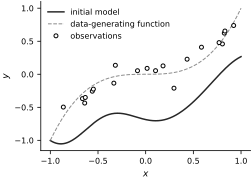

In [6]:
x_train = random.uniform(inputs_key, (20, 1), minval=-1.0, maxval=1.0)
y_train = x_train[:, 0] ** 3 + 0.1 * random.normal(noise_key, (20,))

fig, ax = new_figure(size="half_standard")
ax.plot(
    x_plot[:, 0],
    initial_prediction,
    color="0.15",
    linestyle="-",
    label="initial model",
)
ax.plot(
    x_plot[:, 0],
    x_plot[:, 0] ** 3,
    color="0.55",
    linestyle="--",
    linewidth=1.0,
    label="data-generating function",
)
ax.plot(
    x_train[:, 0],
    y_train,
    linestyle="none",
    marker="o",
    markerfacecolor="white",
    markeredgecolor="black",
    label="observations",
)
ax.set(xlabel="$x$", ylabel="$y$")
ax.legend(loc="best")
_ = finalize_axes(keep_box=False)

The mean-squared-error loss is the scalar function

$$
L(w,c,\sigma^2)=\frac{1}{N}\sum_{i=1}^{N}\left[y_i-f(x_i;w,c,\sigma)\right]^2.
$$

A scalar output matters because `jax.grad` represents the reverse-mode derivative as a gradient with the same shape as the differentiated argument.

In [7]:
def loss(weights, centers, sigma2, x, y):
    prediction = model(x, weights, centers, sigma2)
    return jnp.mean((y - prediction) ** 2)

`value_and_grad` evaluates $L$ and $\nabla_wL$ together. For a scalar loss, this is the reverse-mode calculation from the preceding section with output cotangent $1$. The keyword `argnums=0` selects the first argument, the weight vector.

In [8]:
loss_and_weight_grad = jit(value_and_grad(loss, argnums=0))

In [9]:
loss_value, weight_gradient = loss_and_weight_grad(
    weights, centers, sigma2, x_train, y_train
)
print(f"loss = {float(loss_value):.6f}")
print(f"weight-gradient shape = {weight_gradient.shape}")

loss = 0.357285
weight-gradient shape = (10,)


A tuple of argument indices asks for several derivatives in one reverse-mode transformation. With `argnums=(0, 1, 2)`, JAX returns $\nabla_wL$, $\nabla_cL$, and $\partial L/\partial\sigma^2$ in that order.

In [10]:
loss_and_full_grad = jit(value_and_grad(loss, argnums=(0, 1, 2)))

The returned derivatives match the shapes of the corresponding inputs: the weights form a vector, the centers form a matrix, and $\sigma^2$ is a scalar.

In [11]:
loss_value, (weight_gradient, center_gradient, sigma2_gradient) = (
    loss_and_full_grad(weights, centers, sigma2, x_train, y_train)
)
print("weights:", weight_gradient.shape)
print("centers:", center_gradient.shape)
print("sigma2:", sigma2_gradient.shape)

weights: (10,)
centers: (10, 1)
sigma2: ()


## Directional derivative check

A centered finite difference provides an independent diagnostic for the automatic derivative. For a unit direction $v$ in weight space,

$$
D_vL=\nabla_wL^{\mathsf T}v
\approx\frac{L(w+\varepsilon v,c,\sigma^2)-L(w-\varepsilon v,c,\sigma^2)}{2\varepsilon}.
$$

The finite difference has truncation and roundoff error; it is used only to check the automatic derivative.

In [12]:
direction = random.normal(direction_key, weights.shape)
direction = direction / jnp.linalg.norm(direction)
directional_ad = jnp.vdot(weight_gradient, direction)

epsilon = 1e-3
loss_plus = loss(
    weights + epsilon * direction, centers, sigma2, x_train, y_train
)
loss_minus = loss(
    weights - epsilon * direction, centers, sigma2, x_train, y_train
)
directional_fd = (loss_plus - loss_minus) / (2.0 * epsilon)
relative_error = jnp.abs(directional_ad - directional_fd) / jnp.maximum(
    jnp.abs(directional_fd), 1e-12
)

steps = jnp.linspace(-0.5, 0.5, 101)
loss_slice = vmap(
    lambda step: loss(
        weights + step * direction, centers, sigma2, x_train, y_train
    )
)(steps)
linearization = loss_value + steps * directional_ad

print(f"AD directional derivative = {float(directional_ad):.6f}")
print(f"finite-difference check = {float(directional_fd):.6f}")
print(f"relative difference = {float(relative_error):.2e}")

AD directional derivative = 0.112631
finite-difference check = 0.112623
relative difference = 7.07e-05


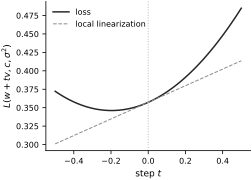

In [13]:
fig, ax = new_figure(size="half_standard")
ax.plot(steps, loss_slice, color="0.15", linestyle="-", label="loss")
ax.plot(
    steps,
    linearization,
    color="0.55",
    linestyle="--",
    linewidth=1.0,
    label="local linearization",
)
ax.axvline(0.0, color="0.75", linestyle=":", linewidth=1.0)
ax.set(xlabel="step $t$", ylabel=r"$L(w+t v,c,\sigma^2)$")
ax.legend(loc="best")
_ = finalize_axes(keep_box=False)

## Further reading

The JAX documentation develops [`grad` and `value_and_grad`](https://docs.jax.dev/en/latest/automatic-differentiation.html), the underlying [`jvp` and `vjp` transformations](https://docs.jax.dev/en/latest/jacobian-vector-products.html), and additional constructions in the [Autodiff Cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html).